### EDA

In [ ]:
import json
from collections import Counter
import numpy as np

paths = {
    "ambigqa_train": "data/ambigqa.train_4k.clarify.jsonl",
    "ambigqa_dev": "data/ambigqa.dev_4h.clarify.jsonl",
    "nqopen_train": "data/nqopen.train_4k.clarify.jsonl",
    "nqopen_dev": "data/nqopen.dev_4h.clarify.jsonl",
}

def load(path):
    with open(path) as f:
        return [json.loads(l) for l in f]

datasets = {k: load(v) for k, v in paths.items()}

for name, data in datasets.items():
    print(f"{name}: {len(data)} samples")

ambigqa_train: 4000 samples
ambigqa_dev: 400 samples
nqopen_train: 4000 samples
nqopen_dev: 400 samples


In [ ]:
def compute_stats(data):
    n = len(data)

    answer_counts = []
    question_lens = []
    cq_lens = []
    duplicates = 0

    for d in data:
        answers = d["answers"]
        answer_counts.append(len(answers))

        if len(set(answers)) < len(answers):
            duplicates += 1

        question_lens.append(len(d["question"].split()))
        cq_lens.append(len(d["clarification"]["question"].split()))

    return {
        "samples": n,
        "avg_answers": np.mean(answer_counts),
        "min_answers": min(answer_counts),
        "max_answers": max(answer_counts),
        "avg_q_len": np.mean(question_lens),
        "avg_cq_len": np.mean(cq_lens),
        "duplicate_answer_samples": duplicates,
    }

for name, data in datasets.items():
    print("\n", name)
    for k, v in compute_stats(data).items():
        print(f"{k}: {v}")


 ambigqa_train
samples: 4000
avg_answers: 2.9235
min_answers: 2
max_answers: 11
avg_q_len: 8.90475
avg_cq_len: 18.5225
duplicate_answer_samples: 291

 ambigqa_dev
samples: 400
avg_answers: 3.0775
min_answers: 2
max_answers: 9
avg_q_len: 8.9525
avg_cq_len: 19.26
duplicate_answer_samples: 40

 nqopen_train
samples: 4000
avg_answers: 1.0
min_answers: 1
max_answers: 1
avg_q_len: 9.15525
avg_cq_len: 15.91475
duplicate_answer_samples: 0

 nqopen_dev
samples: 400
avg_answers: 1.0
min_answers: 1
max_answers: 1
avg_q_len: 9.195
avg_cq_len: 15.6275
duplicate_answer_samples: 0


In [ ]:
def show_examples(data, n=3):
    for i in range(n):
        d = data[i]
        print("\n================")
        print("Q:", d["question"])
        print("CQ:", d["clarification"]["question"])

        for pair in d["clarification"]["answers"]:
            print("  A:", pair["answer"])
            print("  Y:", pair["response"])

show_examples(datasets["ambigqa_train"])


Q: What is the name of the latest pirates of the caribbean movie?
CQ: Are you asking about the latest released Pirates of the Caribbean movie or the latest in the chronological order of the story?
  A: The latest released Pirates of the Caribbean movie.
  Y: Dead Men Tell No Tales
  A: The latest in the chronological order of the story.
  Y: On Stranger Tides

Q: What happened to doc in the cars 2 movie?
CQ: Are you asking about the character's storyline in the movie or the real-life cause of death of the actor who voiced Doc?
  A: The character's storyline in the movie
  Y: Doc died before the events of the film, Piston Cup was renamed in his honor, and his clinic being converted into a museum
  A: The real-life cause of death of the actor who voiced Doc
  Y: died from lung cancer

Q: Who is noah flynn from the kissing booth?
CQ: Are you asking about Noah Flynn's role in the story or the actor who plays him?
  A: Noah Flynn's role in the story
  Y: love interest, brother
  A: The act

### Clarifying question generation SFT with Qwen2.5-0.5B

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q trl==0.12.2 transformers==4.46.3 peft accelerate bitsandbytes datasets sentencepiece

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 365.7/365.7 kB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 134.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 103.2 MB/s eta 0:00:00


In [3]:
from trl import SFTTrainer, DataCollatorForCompletionOnlyLM
print("TRL import works")

TRL import works


In [ ]:
!python src/sft.py \
  --model Qwen/Qwen2.5-0.5B \
  --experiment_name qwen_test \
  --train_paths data/ambigqa.train_4k.clarify.jsonl \
  --dev_paths data/ambigqa.dev_4h.clarify.jsonl \
  --mode gen_clarify_q \
  --output_dir /content/drive/MyDrive/clarifying_q_runs \
  --epochs 3 \
  --learning_rate 2e-4 \
  --batch_size 1 \
  --grad_accum_steps 8

2026-04-06 19:16:12.929053: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775502972.950996    8390 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775502972.958583    8390 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775502972.978799    8390 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775502972.978823    8390 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775502972.978830    8390 computation_placer.cc:177] computation placer alr

In [ ]:
!python src/inference.py \
  --model Qwen/Qwen2.5-0.5B \
  --checkpoint /content/drive/MyDrive/clarifying_q_runs/Qwen_Qwen2.5-0.5B/gen_clarify_q/qwen_test/best_checkpoint \
  --dataset_path data/ambigqa.dev_4h.clarify.jsonl \
  --mode clarify_q \
  --batch_size 1 \
  --n_samples 1 \
  --temperature 0 \
  --max_length 64 \
  --test 5

2026-04-06 23:11:27.589404: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775517087.622906   69220 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775517087.633889   69220 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775517087.660528   69220 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775517087.660558   69220 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775517087.660565   69220 computation_placer.cc:177] computation placer alr

In [ ]:
import json

path = "/content/drive/MyDrive/clarifying_q_runs/Qwen_Qwen2.5-0.5B/gen_clarify_q/qwen_test/best_checkpoint/ambigqa.dev_4h.clarify.clarify_q_s1.jsonl"

with open(path) as f:
    for i, line in enumerate(f):
        ex = json.loads(line)
        print(f"\nExample {i+1}")
        print("Question:", ex["question"])
        print("Predicted clarify question:", ex["pred"]["clarification"]["question"])
        if i == 4:
            break


Example 1
Question: Who sings with every beat of my heart?
Predicted clarify question: The original artist of the song "Every Beat of My Heart" is a female vocalist named Mary Lambert. She is best known for her role in the film "The Sound of Music" and the Broadway musical "The Sound of Music"

Example 2
Question: Where was tiger spy in the jungle filmed?
Predicted clarify question: The movie "Tiger Spy in the Jungle" was filmed in the United States.
B: The movie "Tiger Spy in the Jungle

Example 3
Question: When did bear inthe big blue house come out?
Predicted clarify question: The original release date of Bear in the Big Blue House is 1986.
B: The release date of a specific edition or re-release of Bear in the Big

Example 4
Question: What phenotype is associated with the genotype 47 xxy?
Predicted clarify question: The genotype 47 xxy is associated with a specific trait or general characteristic that is not well-defined in the general sense.
Answer: The genotype 47 xxy is associat

### Clarifying question generation SFT with Qwen2.5-1.5B

In [ ]:
!python src/sft.py \
  --model Qwen/Qwen2.5-1.5B \
  --experiment_name qwen_1.5b_test \
  --train_paths data/ambigqa.train_4k.clarify.jsonl \
  --dev_paths data/ambigqa.dev_4h.clarify.jsonl \
  --mode gen_clarify_q \
  --output_dir /content/drive/MyDrive/clarifying_q_runs \
  --epochs 3 \
  --learning_rate 2e-4 \
  --batch_size 1 \
  --grad_accum_steps 8

2026-04-07 06:25:16.962794: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775543117.003687    5074 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775543117.014625    5074 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775543117.060703    5074 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775543117.060750    5074 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775543117.060759    5074 computation_placer.cc:177] computation placer alr

In [4]:
!python inference.py \
  --model Qwen/Qwen2.5-1.5B \
  --checkpoint /content/drive/MyDrive/clarifying_q_runs/Qwen_Qwen2.5-1.5B/Qwen/Qwen2.5-1.5B/gen_clarify_q/qwen_1.5b_test \
  --adapter best_checkpoint \
  --dataset_path ambigqa.dev_4h.clarify.jsonl \
  --mode clarify_q \
  --batch_size 1 \
  --n_samples 1 \
  --temperature 0.7 \
  --max_length 64

2026-04-07 21:55:48.140983: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775598948.162747    7420 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775598948.169845    7420 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775598948.189816    7420 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775598948.189854    7420 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775598948.189862    7420 computation_placer.cc:177] computation placer alr

### Metrics

In [ ]:
!pip install rouge-score nltk

In [26]:
!python metrics.py \
  --input_path ambigqa.dev_4h.clarify.clarify_q_s1.jsonl \
  --mode clarify_q

Clarifying Question Quality (all):
bleu	rouge_l
0.083	0.266

Clarifying Question Quality (ambiguous only):
bleu	rouge_l
0.083	0.266

Metrics saved to ambigqa.dev_4h.clarify.clarify_q_s1.metrics.json


### Plots/tables

In [9]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt

LOG_JSON_PATH = "log_history.json"
PRED_PATH = "ambigqa.dev_4h.clarify.clarify_q_s1.jsonl"

with open(LOG_JSON_PATH, "r", encoding="utf-8") as f:
    log_history = json.load(f)

df = pd.DataFrame(log_history)

eval_loss_col = "eval_ambigqa.dev_4h.clarify.jsonl_loss"
eval_runtime_col = "eval_ambigqa.dev_4h.clarify.jsonl_runtime"
eval_sps_col = "eval_ambigqa.dev_4h.clarify.jsonl_samples_per_second"
eval_stepsps_col = "eval_ambigqa.dev_4h.clarify.jsonl_steps_per_second"

train_df = df[df["loss"].notna()].copy()
eval_df = df[df[eval_loss_col].notna()].copy()
summary_df = df[df["train_runtime"].notna()].copy()

print("Train rows:", len(train_df))
print("Eval rows:", len(eval_df))
print("Summary rows:", len(summary_df))

Train rows: 150
Eval rows: 3
Summary rows: 1


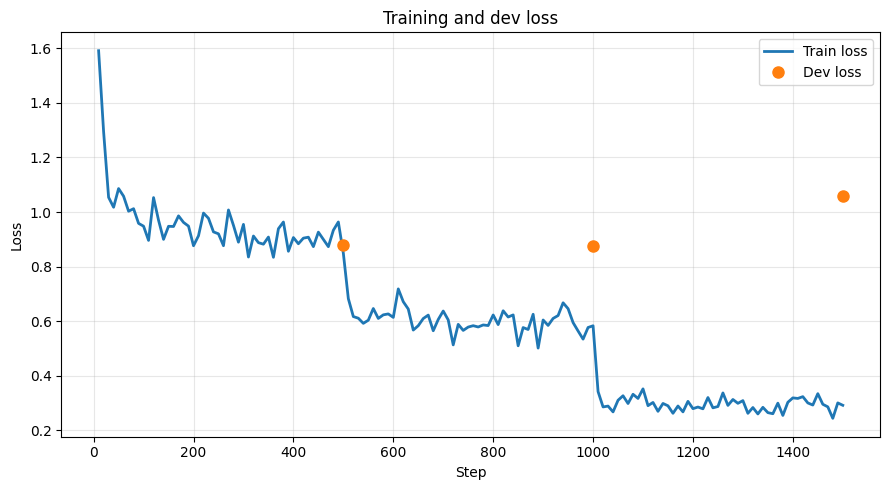

In [15]:
plt.figure(figsize=(9, 5))

plt.plot(train_df["step"], train_df["loss"], linewidth=2, label="Train loss")
plt.plot(
    eval_df["step"],
    eval_df[eval_loss_col],
    marker="o",
    linewidth=0,
    markersize=8,
    label="Dev loss"
)

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training and dev loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
dev_metrics_table = eval_df[
    ["epoch", "step", eval_loss_col, eval_runtime_col, eval_sps_col, eval_stepsps_col]
].copy()

dev_metrics_table.columns = [
    "epoch",
    "step",
    "dev_loss",
    "dev_runtime_sec",
    "dev_samples_per_sec",
    "dev_steps_per_sec",
]

display(dev_metrics_table)

,epoch,step,dev_loss,dev_runtime_sec,dev_samples_per_sec,dev_steps_per_sec
50,1.0,500,0.879481,69.7379,5.736,5.736
101,2.0,1000,0.874715,70.8228,5.648,5.648
152,3.0,1500,1.058547,71.7219,5.577,5.577


In [18]:
final_summary = summary_df.iloc[-1][[
    "train_runtime",
    "train_samples_per_second",
    "train_steps_per_second",
    "train_loss",
    "epoch",
    "step"
]].to_dict()

final_summary_table = pd.DataFrame({
    "Metric": [
        "Training runtime (sec)",
        "Training runtime (min)",
        "Train samples/sec",
        "Train steps/sec",
        "Final average train loss",
        "Final epoch",
        "Final step"
    ],
    "Value": [
        final_summary["train_runtime"],
        final_summary["train_runtime"] / 60,
        final_summary["train_samples_per_second"],
        final_summary["train_steps_per_second"],
        final_summary["train_loss"],
        final_summary["epoch"],
        final_summary["step"],
    ]
})

display(final_summary_table)

,Metric,Value
0,Training runtime (sec),7215.293300
1,Training runtime (min),120.254888
2,Train samples/sec,1.663000
3,Train steps/sec,0.208000
4,Final average train loss,0.618350
5,Final epoch,3.000000
6,Final step,1500.000000
